In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/Melvin/Downloads/task_Dataset.csv")

In [4]:
df.head()

,task_id,task_name,project_id,assigned_employee,deadline,progress,status
0,T001,UI Design,P041,EMP008,2026-11-27,43,In Progress
1,T002,Login Module,P009,EMP048,2026-11-19,98,Completed
2,T003,Deployment,P006,EMP038,2026-08-29,3,Not Started
3,T004,Integration Testing,P015,EMP033,2026-08-28,84,In Progress
4,T005,Security Testing,P027,EMP015,2026-11-08,15,In Progress


In [6]:
df.shape

(500, 7)

In [8]:
print(df.columns.tolist())

['task_id', 'task_name', 'project_id', 'assigned_employee', 'deadline', 'progress', 'status']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   task_id            500 non-null    object
 1   task_name          500 non-null    object
 2   project_id         500 non-null    object
 3   assigned_employee  500 non-null    object
 4   deadline           500 non-null    object
 5   progress           500 non-null    int64 
 6   status             500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [10]:
#Convert deadline into date format
df["deadline"] = pd.to_datetime(df["deadline"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   task_id            500 non-null    object        
 1   task_name          500 non-null    object        
 2   project_id         500 non-null    object        
 3   assigned_employee  500 non-null    object        
 4   deadline           500 non-null    datetime64[ns]
 5   progress           500 non-null    int64         
 6   status             500 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 27.5+ KB


**1. DATA OVERVIEW**


In [14]:
# Total Task
total_tasks = len(df)

print("Total Tasks:", total_tasks)

Total Tasks: 500


In [15]:
#missing values
df.isnull().sum()

task_id              0
task_name            0
project_id           0
assigned_employee    0
deadline             0
progress             0
status               0
dtype: int64

In [16]:
#duplicate records
df.duplicated().sum()

np.int64(0)

In [17]:
#duplicate raw
df[df.duplicated()]

,task_id,task_name,project_id,assigned_employee,deadline,progress,status


In [18]:
#unique projects
unique_projects = df["project_id"].nunique()

print("Unique Projects:", unique_projects)

Unique Projects: 50


In [19]:
#unique project id's
df["project_id"].unique()

array(['P041', 'P009', 'P006', 'P015', 'P027', 'P049', 'P023', 'P035',
       'P037', 'P011', 'P042', 'P045', 'P024', 'P008', 'P005', 'P017',
       'P019', 'P033', 'P001', 'P020', 'P050', 'P029', 'P022', 'P014',
       'P013', 'P007', 'P016', 'P012', 'P043', 'P004', 'P039', 'P046',
       'P048', 'P038', 'P025', 'P026', 'P047', 'P036', 'P044', 'P030',
       'P010', 'P028', 'P032', 'P003', 'P018', 'P040', 'P031', 'P021',
       'P002', 'P034'], dtype=object)

**DATA OVERVIEW SUMMARY**

In [20]:
data_overview = pd.DataFrame({
    "Metric": [
        "Total Tasks",
        "Missing Values",
        "Duplicate Records",
        "Unique Projects",
        "Unique Employees"
    ],
    "Value": [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["project_id"].nunique(),
        df["assigned_employee"].nunique()
    ]
})

data_overview

,Metric,Value
0,Total Tasks,500
1,Missing Values,0
2,Duplicate Records,0
3,Unique Projects,50
4,Unique Employees,50


**2. VISUALIZATIONS**

**Task Status Distribution**


In [21]:
#status counts
status_counts = df["status"].value_counts()

print(status_counts)

status
In Progress    227
Completed      125
Not Started     61
On Hold         59
Cancelled       28
Name: count, dtype: int64


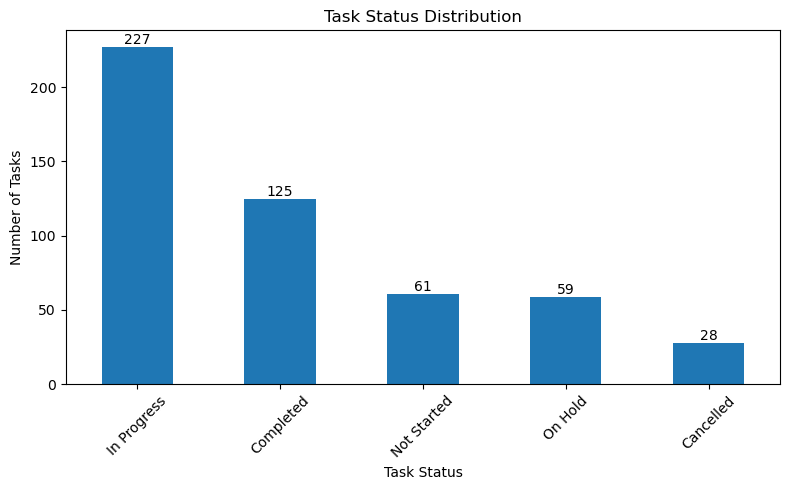

In [23]:
status_counts = df["status"].value_counts()

ax = status_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Task Status Distribution")
plt.xlabel("Task Status")
plt.ylabel("Number of Tasks")
plt.xticks(rotation=45)

for i, value in enumerate(status_counts):
    plt.text(
        i,
        value + 2,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

**Task Progress Distribution**

In [24]:
df["progress"].describe()

count    500.000000
mean      54.770000
std       32.218273
min        0.000000
25%       28.000000
50%       56.000000
75%       86.250000
max      100.000000
Name: progress, dtype: float64

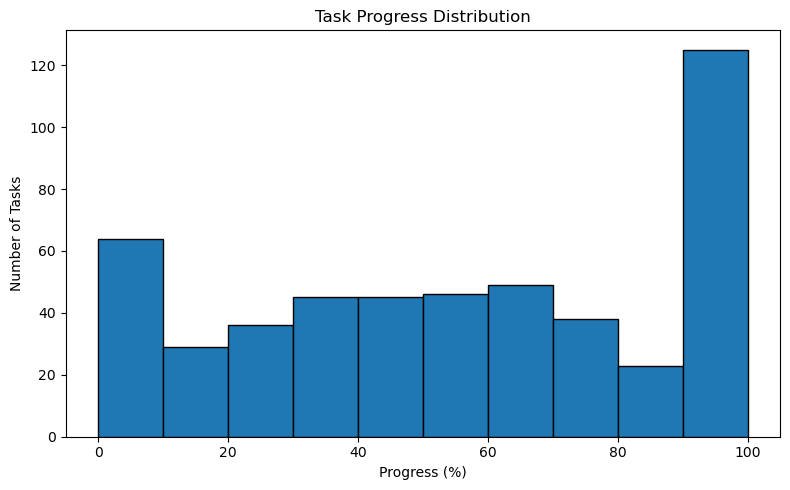

In [25]:
# This chart tells how tasks are distributed between 0% - 100 %

plt.figure(figsize=(8, 5))

plt.hist(
    df["progress"],
    bins=10,
    edgecolor="black"
)

plt.title("Task Progress Distribution")
plt.xlabel("Progress (%)")
plt.ylabel("Number of Tasks")

plt.tight_layout()
plt.show()

**Tasks per Project**

In [32]:
#task for each project
tasks_per_project = df["project_id"].value_counts()

print(tasks_per_project)

project_id
P016    16
P005    16
P022    15
P019    14
P024    14
P049    13
P030    13
P007    12
P006    12
P031    12
P027    12
P037    12
P050    12
P048    12
P009    12
P036    11
P040    11
P029    11
P034    11
P023    11
P011    11
P004    10
P033    10
P013    10
P008    10
P045    10
P043    10
P042    10
P047     9
P001     9
P038     9
P028     9
P039     9
P035     9
P021     9
P017     9
P015     8
P018     8
P020     8
P025     8
P044     8
P012     8
P026     7
P046     7
P014     7
P041     6
P010     5
P032     5
P003     5
P002     5
Name: count, dtype: int64


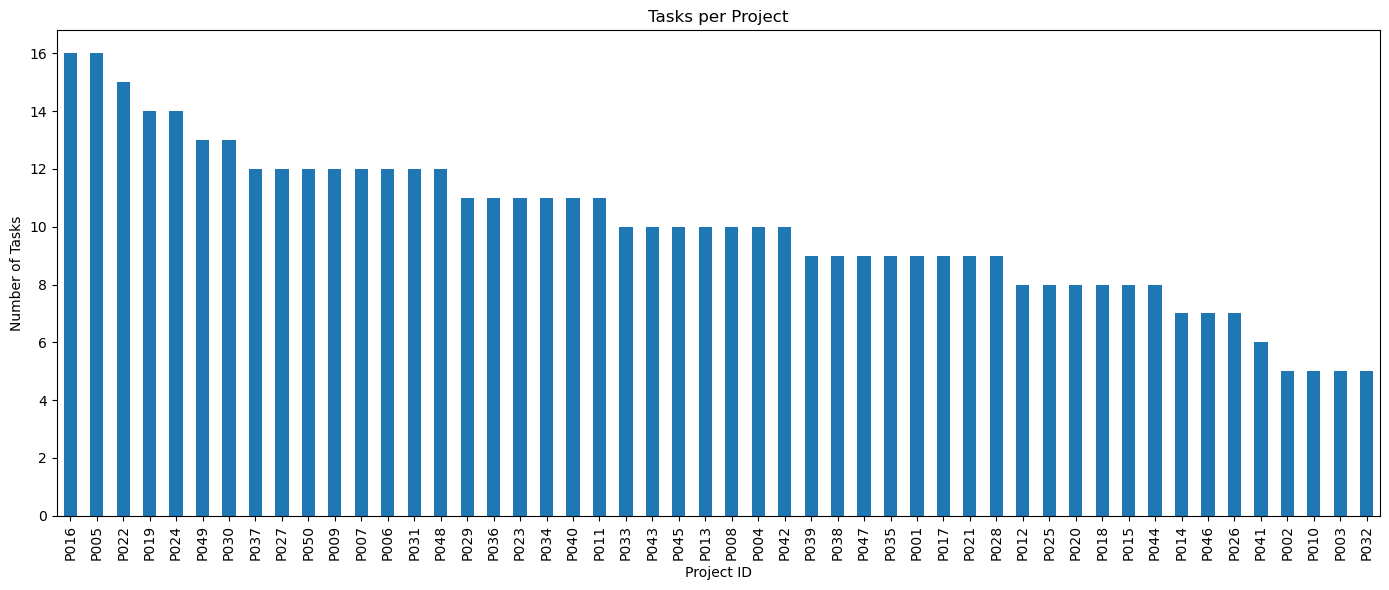

In [35]:
plt.figure(figsize=(14, 6))

tasks_per_project.plot(kind="bar")

plt.title("Tasks per Project")
plt.xlabel("Project ID")
plt.ylabel("Number of Tasks")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [36]:
# top 10 projects
top_projects = tasks_per_project.head(10)

top_projects

project_id
P016    16
P005    16
P022    15
P019    14
P024    14
P049    13
P030    13
P037    12
P027    12
P050    12
dtype: int64

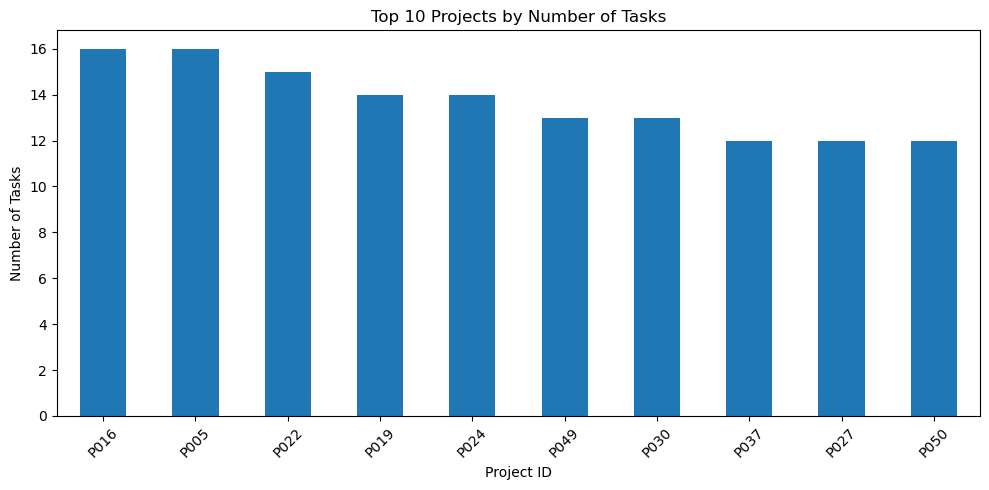

In [37]:
plt.figure(figsize=(10, 5))

top_projects.plot(kind="bar")

plt.title("Top 10 Projects by Number of Tasks")
plt.xlabel("Project ID")
plt.ylabel("Number of Tasks")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Employee-wise Task Allocation**

In [38]:
#number of tasks assigned to every employee
employee_tasks = df["assigned_employee"].value_counts()

employee_tasks

assigned_employee
EMP043    18
EMP036    18
EMP003    16
EMP030    16
EMP005    14
EMP042    14
EMP008    13
EMP021    13
EMP020    13
EMP002    13
EMP024    12
EMP010    12
EMP009    12
EMP004    12
EMP031    12
EMP047    12
EMP039    11
EMP048    11
EMP035    11
EMP015    11
EMP040    10
EMP029    10
EMP049    10
EMP016    10
EMP006    10
EMP034    10
EMP038     9
EMP013     9
EMP018     9
EMP011     9
EMP023     8
EMP014     8
EMP032     8
EMP050     8
EMP044     8
EMP017     8
EMP012     8
EMP046     8
EMP027     8
EMP045     7
EMP028     7
EMP033     7
EMP041     7
EMP022     6
EMP007     6
EMP037     6
EMP026     6
EMP019     6
EMP001     5
EMP025     5
Name: count, dtype: int64

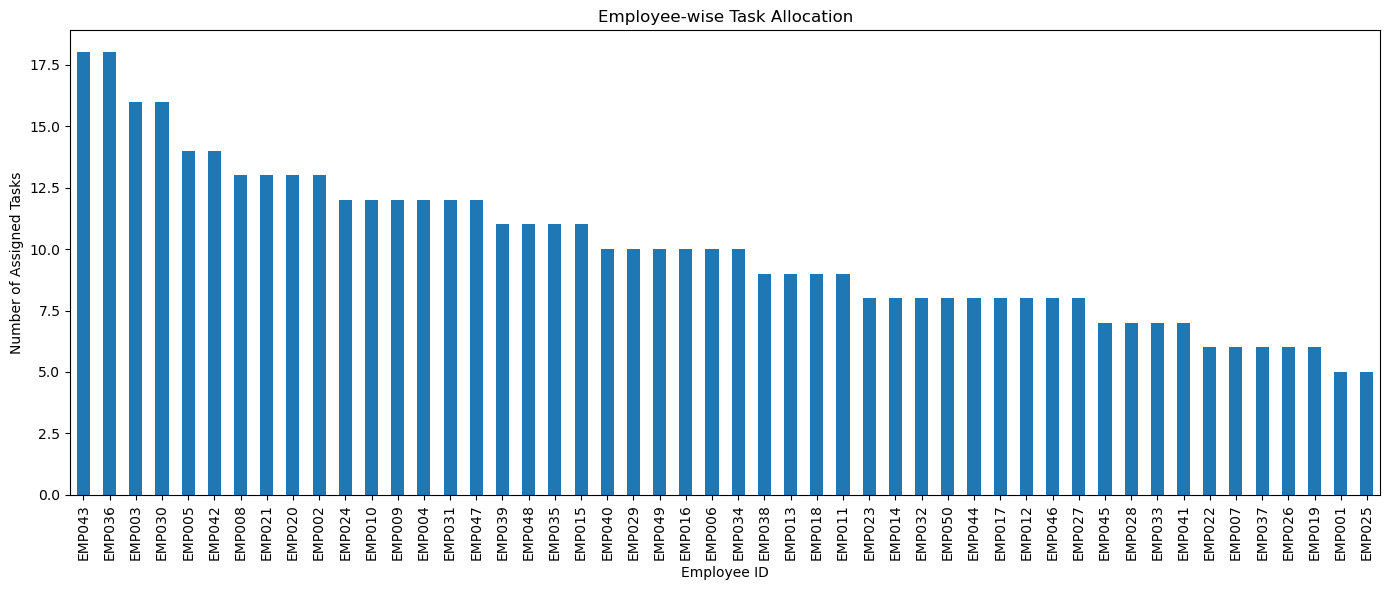

In [39]:
plt.figure(figsize=(14, 6))

employee_tasks.plot(kind="bar")

plt.title("Employee-wise Task Allocation")
plt.xlabel("Employee ID")
plt.ylabel("Number of Assigned Tasks")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [40]:
#Top employees with the highest task allocation
employee_tasks.head(10)

assigned_employee
EMP043    18
EMP036    18
EMP003    16
EMP030    16
EMP005    14
EMP042    14
EMP008    13
EMP021    13
EMP020    13
EMP002    13
Name: count, dtype: int64

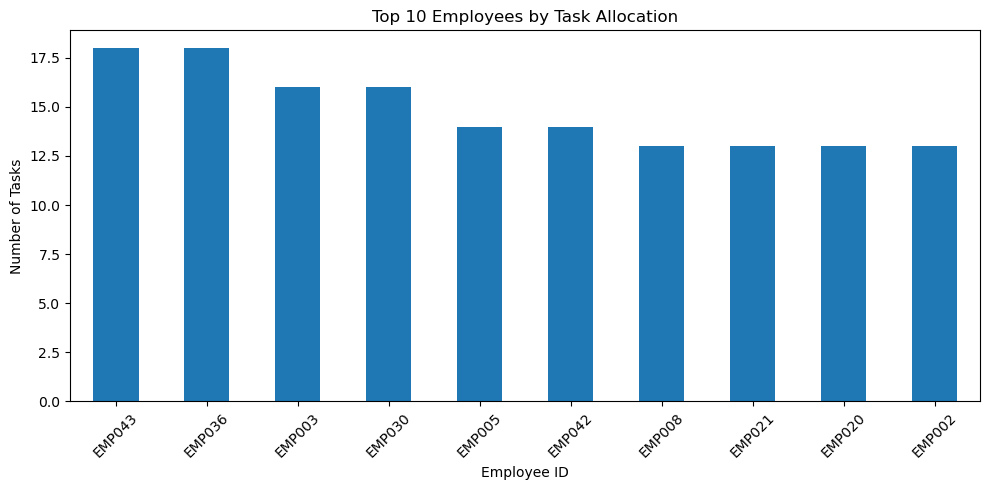

In [41]:
top_employees = employee_tasks.head(10)

plt.figure(figsize=(10, 5))

top_employees.plot(kind="bar")

plt.title("Top 10 Employees by Task Allocation")
plt.xlabel("Employee ID")
plt.ylabel("Number of Tasks")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Deadline Analysis**

In [44]:
analysis_date = pd.Timestamp("2026-08-29")

In [45]:
#calculate days remaining
df["days_to_deadline"] = (
    df["deadline"] - analysis_date
).dt.days

In [46]:
#check
df[
    [
        "task_id",
        "deadline",
        "days_to_deadline"
    ]
].head()

,task_id,deadline,days_to_deadline
0,T001,2026-11-27,90
1,T002,2026-11-19,82
2,T003,2026-08-29,0
3,T004,2026-08-28,-1
4,T005,2026-11-08,71


In [47]:
#deadline categories
def deadline_category(days):

    if days < 0:
        return "Overdue"

    elif days == 0:
        return "Due Today"

    elif days <= 7:
        return "Due in 7 Days"

    else:
        return "Later"

In [48]:
df["deadline_category"] = df["days_to_deadline"].apply(
    deadline_category
)

In [49]:
df[
    [
        "task_id",
        "deadline",
        "days_to_deadline",
        "deadline_category"
    ]
].head(10)

,task_id,deadline,days_to_deadline,deadline_category
0,T001,2026-11-27,90,Later
1,T002,2026-11-19,82,Later
2,T003,2026-08-29,0,Due Today
3,T004,2026-08-28,-1,Overdue
4,T005,2026-11-08,71,Later
5,T006,2026-10-07,39,Later
6,T007,2026-09-05,7,Due in 7 Days
7,T008,2026-12-06,99,Later
8,T009,2026-09-04,6,Due in 7 Days
9,T010,2026-08-30,1,Due in 7 Days


In [50]:
#count of deadline categories
deadline_counts = df["deadline_category"].value_counts()

deadline_counts

deadline_category
Later            452
Due in 7 Days     29
Overdue           13
Due Today          6
Name: count, dtype: int64

**Deadline Analysis chart**

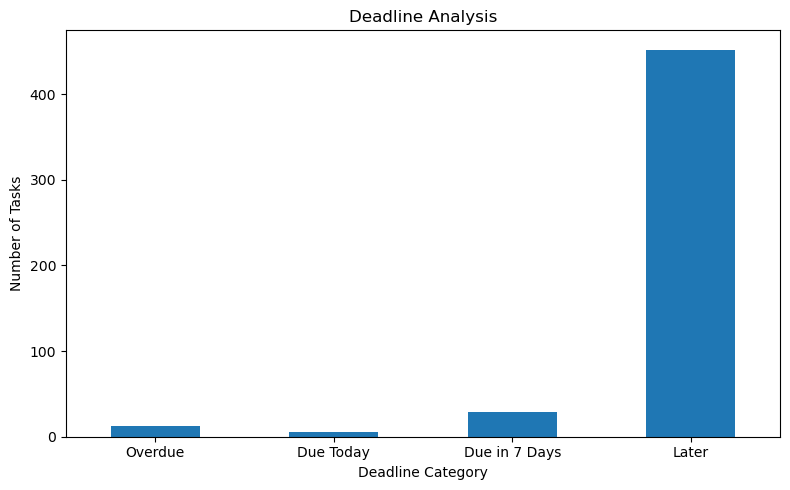

In [53]:
plt.figure(figsize=(8, 5))

deadline_counts.plot(kind="bar")

plt.title("Deadline Analysis")
plt.xlabel("Deadline Category")
plt.ylabel("Number of Tasks")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [54]:
#overdue tasks that are not completed
overdue_tasks = df[
    (df["deadline"] < analysis_date) &
    (df["status"] != "Completed")
]

In [55]:
overdue_tasks

,task_id,task_name,project_id,assigned_employee,deadline,progress,status,progress_category,days_to_deadline,deadline_category
3,T004,Integration Testing,P015,EMP033,2026-08-28,84,In Progress,76-100%,-1,Overdue
114,T115,Requirements Analysis,P009,EMP040,2026-08-28,47,On Hold,26-50%,-1,Overdue
177,T178,Login Module,P045,EMP032,2026-08-28,38,Cancelled,26-50%,-1,Overdue
206,T207,Report Generation,P037,EMP019,2026-08-27,42,Cancelled,26-50%,-2,Overdue
257,T258,Data Analysis,P002,EMP039,2026-08-28,54,In Progress,51-75%,-1,Overdue
268,T269,Login Module,P019,EMP021,2026-08-25,70,In Progress,51-75%,-4,Overdue
273,T274,Documentation,P019,EMP008,2026-08-27,10,Cancelled,1-25%,-2,Overdue
317,T318,API Development,P040,EMP001,2026-08-27,34,In Progress,26-50%,-2,Overdue
376,T377,Performance Testing,P032,EMP020,2026-08-27,6,Not Started,1-25%,-2,Overdue
411,T412,Registration Module,P007,EMP044,2026-08-25,10,Cancelled,1-25%,-4,Overdue


In [56]:
len(overdue_tasks)

12

In [57]:
#Tasks due within the next 7 days
due_soon = df[
    (df["days_to_deadline"] >= 0) &
    (df["days_to_deadline"] <= 7) &
    (df["status"] != "Completed")
]

In [58]:
due_soon

,task_id,task_name,project_id,assigned_employee,deadline,progress,status,progress_category,days_to_deadline,deadline_category
2,T003,Deployment,P006,EMP038,2026-08-29,3,Not Started,1-25%,0,Due Today
6,T007,Login Module,P049,EMP022,2026-09-05,60,In Progress,51-75%,7,Due in 7 Days
8,T009,Documentation,P035,EMP008,2026-09-04,61,In Progress,51-75%,6,Due in 7 Days
52,T053,User Acceptance Testing,P011,EMP004,2026-09-04,14,On Hold,1-25%,6,Due in 7 Days
85,T086,Deployment,P013,EMP024,2026-09-02,68,On Hold,51-75%,4,Due in 7 Days
166,T167,UI Design,P039,EMP017,2026-09-05,17,In Progress,1-25%,7,Due in 7 Days
188,T189,Deployment,P015,EMP050,2026-08-30,75,In Progress,51-75%,1,Due in 7 Days
222,T223,Registration Module,P027,EMP008,2026-08-30,29,On Hold,26-50%,1,Due in 7 Days
266,T267,Report Generation,P034,EMP043,2026-08-30,22,In Progress,1-25%,1,Due in 7 Days
270,T271,Bug Fixing,P036,EMP043,2026-09-03,20,In Progress,1-25%,5,Due in 7 Days


In [59]:
len(due_soon)

21

**3. OBSERVATIONS**

**Observation 1 — Most tasks are currently in progress -227 out of 500 tasks are currently In Progress**

In [60]:
df["status"].value_counts()

status
In Progress    227
Completed      125
Not Started     61
On Hold         59
Cancelled       28
Name: count, dtype: int64

**Observation 2 — Only 25% of all tasks are completed, while a large proportion remains in progress, on hold, or not started.**

In [61]:
completed_percentage = (
    (df["status"] == "Completed").sum()
    / len(df)
) * 100

print(completed_percentage)

25.0


**Observation 3 — Some employees have heavier workloads- Task allocation is not completely balanced. EMP036 and EMP043 each have 18 tasks, while some employees have considerably fewer tasks. Workload redistribution may improve team efficiency**

In [62]:
employee_tasks.head()

assigned_employee
EMP043    18
EMP036    18
EMP003    16
EMP030    16
EMP005    14
Name: count, dtype: int64

**Observation 4 — Some projects have significantly more tasks - Projects P005 and P016 have the largest task volumes, with 16 tasks each. These projects may require additional monitoring and resources**

In [63]:
tasks_per_project.head()

project_id
P016    16
P005    16
P022    15
P019    14
P024    14
dtype: int64

**Observation 5 — Deadline risks exist - As of 29 August 2026, 12 unfinished tasks are already overdue, indicating a potential schedule-risk area that requires immediate attention**

In [64]:
len(overdue_tasks)

12